In [1]:
import sys
from pathlib import Path
from torchvision import transforms,datasets
from torch.utils.data import Subset,DataLoader
from torchvision import models 
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score,precision_score,recall_score
sys.path.append(str(Path("..")))
from src.dataset import train_data,train_path,train_indices,val_indices, val_loader, ood_loader,ood_path
from src.sampler import BalancedBatchSampler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
import numpy as np

torch.Size([32, 3, 256, 256])
torch.Size([32])
tensor([3, 3, 1, 2, 5, 7, 3, 2, 5, 5])


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 2.0)
        )
    ], p=0.2),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data_aug = datasets.ImageFolder(train_path,transform=train_transform)
val_data = datasets.ImageFolder(train_path,transform=val_transform)

train_dataset_aug = Subset(train_data_aug,train_indices)
val_dataset = Subset(val_data,val_indices)

train_data_aug_loader = DataLoader(
    train_dataset_aug,
    batch_size= 32,
    shuffle= True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)


In [4]:
num_classes = len(train_data.classes)

model = models.convnext_tiny(
    weights=models.ConvNeXt_Tiny_Weights.DEFAULT
)

In [5]:
for param in model.parameters():
    param.requires_grad = False


model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    num_classes
)

for param in model.features[6].parameters():
    param.requires_grad = True

for param in model.features[7].parameters():
    param.requires_grad = True


for param in model.classifier.parameters():
    param.requires_grad = True


model = model.to(device)



criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {
        "params": model.features[6].parameters(),
        "lr": 1e-5,

    },
    {
        "params": model.features[7].parameters(),
        "lr": 3e-5,

    },
    {
        "params": model.classifier.parameters(),
        "lr": 1e-3,
    }
])

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=30,
    gamma=0.1
)


num_epochs = 100

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_f1_scores = []
val_precision_scores = []
val_recall_scores = []

val_f1_scores_by_class = []
val_precision_scores_by_class = []
val_recall_scores_by_class = []
best_val_f1 = 0.0
best_epoch = 0



for epoch in range(num_epochs):



    model.train()

    running_train_loss = 0.0

    train_correct = 0
    train_total = 0


    for images, labels in train_data_aug_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


    train_loss = (
        running_train_loss / len(train_data_aug_loader)
    )

    train_accuracy = (
        train_correct / train_total
    )


    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()


            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predicted.cpu().numpy()
            )


    val_loss = (
        running_val_loss / len(val_loader)
    )

    val_accuracy = (
        val_correct / val_total
    )


    # =========================
    # Metrics
    # =========================

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_precision = precision_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )


    # Per-class metrics

    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    precision_by_class = precision_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    recall_by_class = recall_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    val_f1_scores.append(val_f1)

    val_precision_scores.append(val_precision)

    val_recall_scores.append(val_recall)

    val_f1_scores_by_class.append(
        f1_score_by_class
    )

    val_precision_scores_by_class.append(
        precision_by_class
    )

    val_recall_scores_by_class.append(
        recall_by_class
    )


    # =========================
    # Print
    # =========================

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("Precision by each class:")
    print(precision_by_class)

    print("Recall by each class:")
    print(recall_by_class)

    print("F1 Score by each class:")
    print(f1_score_by_class)
    
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/04_ConvNext_Scheduler.pth"
        )

        print(
        f"Best model saved! "
        f"Epoch: {best_epoch} | "
        f"Val Macro F1: {best_val_f1:.4f}"
        )
    scheduler.step()
    print(
        "======================================================================================="
    )


Epoch [1/100] | Train Loss: 0.7808 | Train Acc: 0.7839 | Val Loss: 0.2372 | Val Acc: 0.9425 | Val Precision: 0.9477 | Val Recall: 0.9407 | Val Macro F1: 0.9429
Precision by each class:
[0.96341463 0.91150442 0.95238095 0.89915966 0.97619048 0.92307692
 0.99019608 0.96551724]
Recall by each class:
[0.9875     0.99038462 0.83333333 0.97272727 0.89130435 0.97297297
 0.94392523 0.93333333]
F1 Score by each class:
[0.97530864 0.94930876 0.88888889 0.93449782 0.93181818 0.94736842
 0.96650718 0.94915254]
Best model saved! Epoch: 1 | Val Macro F1: 0.9429


Epoch [2/100] | Train Loss: 0.2163 | Train Acc: 0.9449 | Val Loss: 0.1460 | Val Acc: 0.9507 | Val Precision: 0.9552 | Val Recall: 0.9482 | Val Macro F1: 0.9501
Precision by each class:
[1.         0.96226415 0.97619048 0.86507937 0.98823529 0.91666667
 1.         0.93333333]
Recall by each class:
[0.9875     0.98076923 0.85416667 0.99090909 0.91304348 0.99099099
 0.93457944 0.93333333]
F1 Score by each class:
[0.99371069 0.97142857 0.91111111 0.92372881 0.94915254 0.95238095
 0.96618357 0.93333333]
Best model saved! Epoch: 2 | Val Macro F1: 0.9501


Epoch [3/100] | Train Loss: 0.1365 | Train Acc: 0.9623 | Val Loss: 0.1187 | Val Acc: 0.9630 | Val Precision: 0.9636 | Val Recall: 0.9592 | Val Macro F1: 0.9605
Precision by each class:
[0.9875     0.97169811 0.97647059 0.88617886 0.98850575 0.96491228
 1.         0.93333333]
Recall by each class:
[0.9875     0.99038462 0.86458333 0.99090909 0.93478261 0.99099099
 0.98130841 0.93333333]
F1 Score by each class:
[0.9875     0.98095238 0.91712707 0.93562232 0.96089385 0.97777778
 0.99056604 0.93333333]
Best model saved! Epoch: 3 | Val Macro F1: 0.9605


Epoch [4/100] | Train Loss: 0.0929 | Train Acc: 0.9777 | Val Loss: 0.0930 | Val Acc: 0.9740 | Val Precision: 0.9717 | Val Recall: 0.9698 | Val Macro F1: 0.9706
Precision by each class:
[1.         0.97169811 0.9673913  0.93913043 0.98876404 0.97345133
 1.         0.93333333]
Recall by each class:
[0.9875     0.99038462 0.92708333 0.98181818 0.95652174 0.99099099
 0.99065421 0.93333333]
F1 Score by each class:
[0.99371069 0.98095238 0.94680851 0.96       0.97237569 0.98214286
 0.99530516 0.93333333]
Best model saved! Epoch: 4 | Val Macro F1: 0.9706


Epoch [5/100] | Train Loss: 0.0707 | Train Acc: 0.9812 | Val Loss: 0.0915 | Val Acc: 0.9740 | Val Precision: 0.9719 | Val Recall: 0.9701 | Val Macro F1: 0.9708
Precision by each class:
[1.         0.98095238 0.96808511 0.94736842 0.98876404 0.95652174
 1.         0.93333333]
Recall by each class:
[0.9875     0.99038462 0.94791667 0.98181818 0.95652174 0.99099099
 0.97196262 0.93333333]
F1 Score by each class:
[0.99371069 0.98564593 0.95789474 0.96428571 0.97237569 0.97345133
 0.98578199 0.93333333]
Best model saved! Epoch: 5 | Val Macro F1: 0.9708


...

Epoch [96/100] | Train Loss: 0.0018 | Train Acc: 1.0000 | Val Loss: 0.1036 | Val Acc: 0.9808 | Val Precision: 0.9774 | Val Recall: 0.9795 | Val Macro F1: 0.9784
Precision by each class:
[1.         0.99038462 0.95789474 0.96396396 0.98913043 0.98214286
 1.         0.93548387]
Recall by each class:
[0.9875     0.99038462 0.94791667 0.97272727 0.98913043 0.99099099
 0.99065421 0.96666667]
F1 Score by each class:
[0.99371069 0.99038462 0.95287958 0.96832579 0.98913043 0.98654709
 0.99530516 0.95081967]


Epoch [97/100] | Train Loss: 0.0013 | Train Acc: 1.0000 | Val Loss: 0.1036 | Val Acc: 0.9808 | Val Precision: 0.9774 | Val Recall: 0.9795 | Val Macro F1: 0.9784
Precision by each class:
[1.         0.99038462 0.95789474 0.96396396 0.98913043 0.98214286
 1.         0.93548387]
Recall by each class:
[0.9875     0.99038462 0.94791667 0.97272727 0.98913043 0.99099099
 0.99065421 0.96666667]
F1 Score by each class:
[0.99371069 0.99038462 0.95287958 0.96832579 0.98913043 0.98654709
 0.99530516 0.95081967]


Epoch [98/100] | Train Loss: 0.0042 | Train Acc: 0.9986 | Val Loss: 0.1036 | Val Acc: 0.9808 | Val Precision: 0.9774 | Val Recall: 0.9795 | Val Macro F1: 0.9784
Precision by each class:
[1.         0.99038462 0.95789474 0.96396396 0.98913043 0.98214286
 1.         0.93548387]
Recall by each class:
[0.9875     0.99038462 0.94791667 0.97272727 0.98913043 0.99099099
 0.99065421 0.96666667]
F1 Score by each class:
[0.99371069 0.99038462 0.95287958 0.96832579 0.98913043 0.98654709
 0.99530516 0.95081967]


Epoch [99/100] | Train Loss: 0.0025 | Train Acc: 1.0000 | Val Loss: 0.1036 | Val Acc: 0.9808 | Val Precision: 0.9774 | Val Recall: 0.9795 | Val Macro F1: 0.9784
Precision by each class:
[1.         0.99038462 0.95789474 0.96396396 0.98913043 0.98214286
 1.         0.93548387]
Recall by each class:
[0.9875     0.99038462 0.94791667 0.97272727 0.98913043 0.99099099
 0.99065421 0.96666667]
F1 Score by each class:
[0.99371069 0.99038462 0.95287958 0.96832579 0.98913043 0.98654709
 0.99530516 0.95081967]


Epoch [100/100] | Train Loss: 0.0036 | Train Acc: 0.9986 | Val Loss: 0.1036 | Val Acc: 0.9808 | Val Precision: 0.9774 | Val Recall: 0.9795 | Val Macro F1: 0.9784
Precision by each class:
[1.         0.99038462 0.95789474 0.96396396 0.98913043 0.98214286
 1.         0.93548387]
Recall by each class:
[0.9875     0.99038462 0.94791667 0.97272727 0.98913043 0.99099099
 0.99065421 0.96666667]
F1 Score by each class:
[0.99371069 0.99038462 0.95287958 0.96832579 0.98913043 0.98654709
 0.99530516 0.95081967]


In [6]:

num_classes = len(train_data.classes)

model = models.convnext_tiny(
    weights=models.ConvNeXt_Tiny_Weights.DEFAULT
)
model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    num_classes
)

model = model.to(device)

model.load_state_dict(
    torch.load("../models/04_ConvNext_Scheduler.pth")
)

model = model.to(device)

In [7]:
model.eval()

all_val_labels = []

all_val_predictions = []

all_probabilities = []

all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(outputs,dim=1)

        _, predicted = torch.max(outputs,1)
        
        val_total += labels.size(0)

        val_correct += (predicted == labels).sum().item()


        all_val_labels.extend(labels.cpu().numpy())

        all_val_predictions.extend(predicted.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

        all_logits.extend(outputs.cpu().numpy())


val_accuracy = val_correct / val_total


val_precision = precision_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_recall = recall_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_f1 = f1_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_precision_by_class = precision_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_recall_by_class = recall_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_f1_by_class = f1_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)
print(f"val Accuracy: {val_accuracy:.4f}")


print(
    f"val Macro Precision: "
    f"{val_precision:.4f}"
)

print(
    f"val Macro Recall: "
    f"{val_recall:.4f}"
)

print(
    f"val Macro F1: "
    f"{val_f1:.4f}"
)


print("val Precision by class:")
print(val_precision_by_class)

print("val Recall by class:")
print(val_recall_by_class)

print("val F1 by class:")
print(val_f1_by_class)

val Accuracy: 0.9836
val Macro Precision: 0.9826
val Macro Recall: 0.9823
val Macro F1: 0.9824
val Precision by class:
[1.         0.99047619 0.95789474 0.96396396 1.         0.98214286
 1.         0.96666667]
val Recall by class:
[1.         1.         0.94791667 0.97272727 0.98913043 0.99099099
 0.99065421 0.96666667]
val F1 by class:
[1.         0.99521531 0.95287958 0.96832579 0.99453552 0.98654709
 0.99530516 0.96666667]


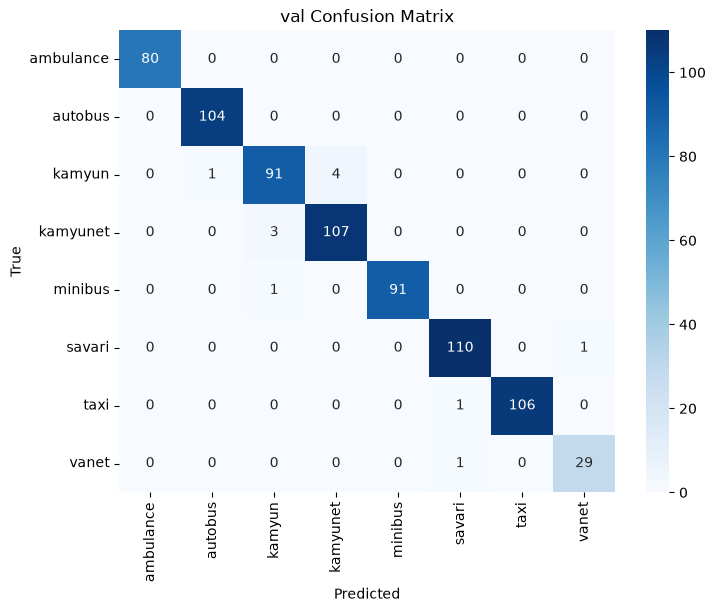

In [8]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

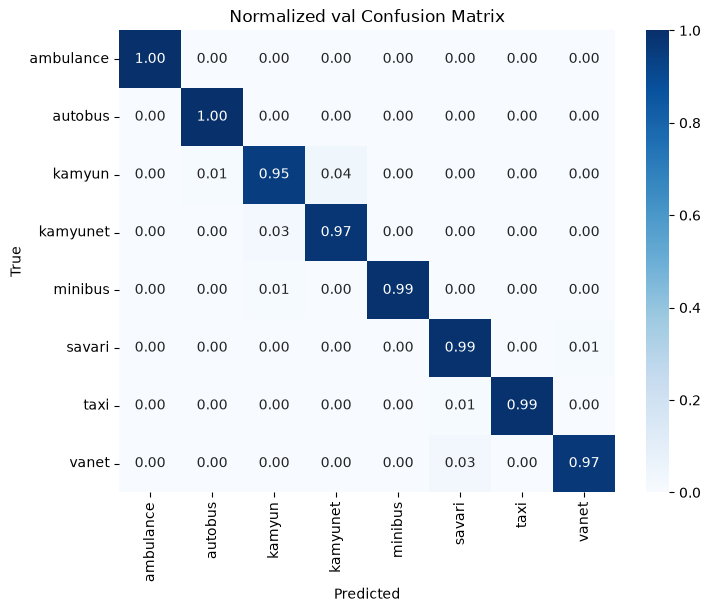

In [9]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()